In [3]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from src.problems import make_rastrigin
from src.stopping_criterion import ExactNonconvexCertificate
from src.optimizer import minimize

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
sigma = 0
alpha = 0.6
eps = 1
eta0 = 0.002
# gamma = 0.51
gamma = 0.51

n = 2
x_min = np.zeros(n)
fun, true_grad, stoch_grad, L = make_rastrigin(n, A=10, sigma=sigma)

x0 = np.r_[1, 1] * 1


stop_criterion = ExactNonconvexCertificate(fun, sigma, alpha, eps, L, true_grad)

report_interval = 1000
x_avg_t, results = minimize(fun, stoch_grad, None, x0, eta0, gamma, stop_criterion, max_iter=500_000, verbose=True, report_interval=report_interval, true_grad=true_grad)

[Iter   1000]  F(x)= 1.98992 | F_avg(x)= 1.99010 | G_avg= 0.14118 | Cert=115.05845
[Iter   2000]  F(x)= 1.98992 | F_avg(x)= 1.99004 | G_avg=0.099801 | Cert=81.33646
[Iter   3000]  F(x)= 1.98992 | F_avg(x)= 1.99002 | G_avg=0.081557 | Cert=66.46728
[Iter   4000]  F(x)= 1.98992 | F_avg(x)= 1.99001 | G_avg=0.070698 | Cert=57.61760
[Iter   5000]  F(x)= 1.98992 | F_avg(x)= 1.99000 | G_avg=0.063292 | Cert=51.58218
[Iter   6000]  F(x)= 1.98992 | F_avg(x)= 1.98999 | G_avg=0.057827 | Cert=47.12807
[Iter   7000]  F(x)= 1.98992 | F_avg(x)= 1.98999 | G_avg= 0.05358 | Cert=43.66645
[Iter   8000]  F(x)= 1.98992 | F_avg(x)= 1.98998 | G_avg=0.050156 | Cert=40.87589
[Iter   9000]  F(x)= 1.98992 | F_avg(x)= 1.98998 | G_avg=0.047319 | Cert=38.56408
[Iter  10000]  F(x)= 1.98992 | F_avg(x)= 1.98997 | G_avg=0.044919 | Cert=36.60800
[Iter  11000]  F(x)= 1.98992 | F_avg(x)= 1.98997 | G_avg=0.042853 | Cert=34.92477
[Iter  12000]  F(x)= 1.98992 | F_avg(x)= 1.98997 | G_avg=0.041051 | Cert=33.45627
[Iter  13000]  

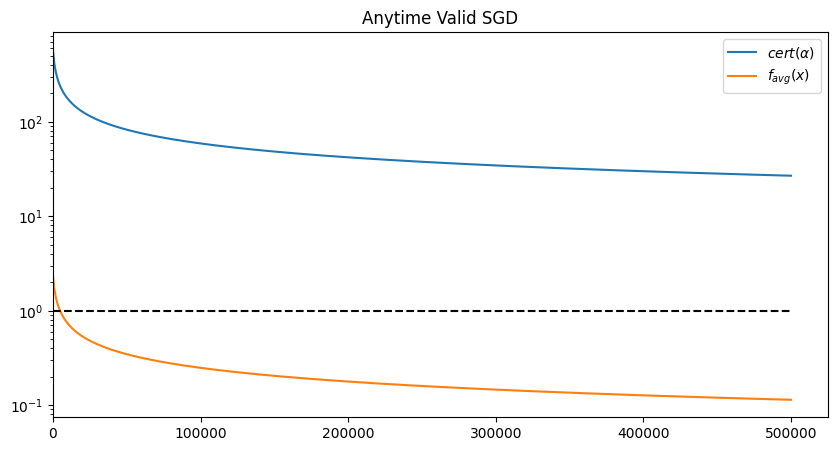

In [44]:
f = results['f']
f_avg = np.r_[results['F_avg']]
g_avg = np.r_[results['G_avg']]
cert = np.r_[results['cert']]

t = np.linspace(1, len(f) * report_interval, len(f))
plt.figure(figsize=(10, 5))
# plt.plot(t, f, label=r"$f_t(x)$")
plt.plot(t, cert, label=r"$cert(\alpha)$")
plt.plot(t, g_avg, label=r"$f_{avg}(x)$")
plt.hlines(y=eps, xmin=0, xmax=np.max(t), linestyles="--", color='black')
plt.xlim(left=0)
plt.yscale('log')
plt.legend(loc='upper right')
plt.title('Anytime Valid SGD')
plt.show()
